# 04 · Playground

**For answering a question somebody actually asks.** The other three notebooks
are a record of decisions already made. This one is a working surface: a
clinician asks something, and the answer gets found here, as a table or a chart.

## Which layer answers what

Picking the wrong layer is the usual reason a question feels hard.

| The question is about… | Query | Because |
|---|---|---|
| **Who is overdue, and how badly** | `care_gap_a1c` (Gold) | One row per patient, already carrying the gap, the priority and the next due date |
| **A patient's history over time** | `silver_observations` | Gold holds only the *latest* A1c — a trend needs every result |
| **When somebody was last seen** | `silver_encounters` | Every visit, not just the most recent |
| **What they are on** | `silver_medications` | Gold has a count; the names are here |
| **Why a patient is *missing*** | `quarantine` · `identity_review` | The whole reason those tables exist |

Rule of thumb: **Gold answers "who", Silver answers "what happened".**

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from caregap.config import DB, A1C, ASOF, GAP_DAYS, sql_list
from caregap.domain.cohort import DIABETES_CODES

pd.set_option("display.width", 180); pd.set_option("display.max_colwidth", 60)

# Read-only: a playground must not be able to change the warehouse.
con = duckdb.connect(str(DB), read_only=True)
DX = sql_list(DIABETES_CODES)

def ask(sql):
    """Run a query and show it as a table."""
    return con.sql(sql).df()

# The validated palette the rest of the project uses - blue and orange only.
BLUE, ORANGE, INK, MUTED, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#dcdcd8", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "figure.dpi": 120,
})

print(f"as of {ASOF} · gap opens after {GAP_DAYS} days · {con.sql('SELECT count(*) FROM care_gap_a1c').fetchone()[0]} patients in the cohort")

as of 2026-08-23 · gap opens after 365 days · 116 patients in the cohort


## Gold questions — "who?"

These are one-liners because Gold was built for them.

### "How many of my diabetic patients are overdue, and who is worst?"

In [2]:
ask("""
SELECT g.priority, g.patient_id[1:8] AS patient, g.age, p.sex,
       g.last_a1c_date AS last_a1c, g.last_a1c_value AS value,
       g.days_overdue, g.a1c_count_2y AS tests_2yr, g.on_insulin,
       g.last_encounter_date AS last_seen
FROM care_gap_a1c g
JOIN silver_patients p USING (patient_id)    -- Gold has no name or sex; Silver does
WHERE g.gap_flag
ORDER BY g.priority
LIMIT 12
""")

,priority,patient,age,sex,last_a1c,value,days_overdue,tests_2yr,on_insulin,last_seen
0,1,dd31b260,85,M,NaT,NaN,<NA>,0,False,2026-05-23
1,2,23018670,79,M,NaT,NaN,<NA>,0,False,2026-07-26
2,3,cb213d00,75,M,NaT,NaN,<NA>,0,False,2026-05-18
3,4,ff8b6ec6,75,M,NaT,NaN,<NA>,0,False,2026-07-05
4,5,8670ef45,73,F,NaT,NaN,<NA>,0,False,2026-08-22
5,6,73321c11,69,M,NaT,NaN,<NA>,0,False,2025-09-23
6,7,e49fe9cd,67,F,NaT,NaN,<NA>,0,False,2026-03-25
7,8,f52c7b09,63,M,NaT,NaN,<NA>,0,False,2026-08-20
8,9,45902090,63,M,NaT,NaN,<NA>,0,False,2026-07-07
9,10,e7932633,62,F,NaT,NaN,<NA>,0,False,2026-03-07


`priority` ranks never-tested first, then most overdue, then highest last value,
then insulin, then age. The nulls in `last_a1c` are not missing data — those
patients have never been tested, which is why they rank above everyone.

### "Who becomes overdue in the next three months?"
The question a care team can actually act on, as opposed to a list of people
already late.

In [3]:
ask(f"""
SELECT CASE WHEN last_a1c_date IS NULL                                         THEN '0 · never tested'
            WHEN gap_flag                                                      THEN '1 · already overdue'
            WHEN date_diff('day', asof_date, next_due_date) <= 30              THEN '2 · due within 30 days'
            WHEN date_diff('day', asof_date, next_due_date) <= 90              THEN '3 · due within 90 days'
            ELSE '4 · later' END AS when_due,
       count(*) AS patients
FROM care_gap_a1c GROUP BY 1 ORDER BY 1
""")

,when_due,patients
0,0 · never tested,21
1,1 · already overdue,4
2,2 · due within 30 days,4
3,3 · due within 90 days,8
4,4 · later,79


### "Is the gap worse in any age group?"

,band,patients,gaps,gap_pct
0,18-44,5,1,20.0
1,45-64,51,15,29.4
2,65-75,39,6,15.4
3,76+,21,3,14.3


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


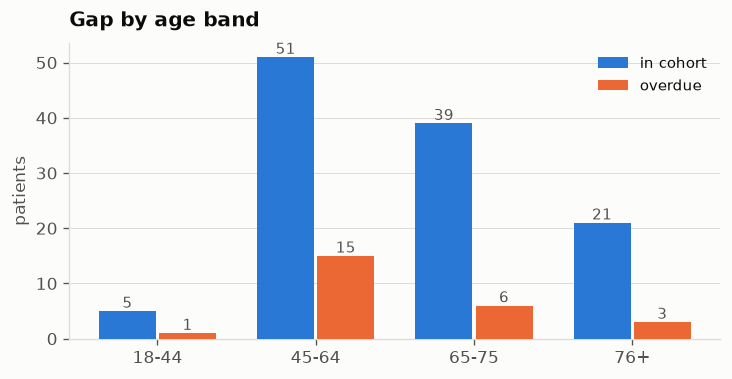

In [4]:
band = ask("""
SELECT CASE WHEN age < 45 THEN '18-44' WHEN age < 65 THEN '45-64'
            WHEN age <= 75 THEN '65-75' ELSE '76+' END AS band,
       count(*) AS patients, count(*) FILTER (WHERE gap_flag) AS gaps,
       round(100.0 * count(*) FILTER (WHERE gap_flag) / count(*), 1) AS gap_pct
FROM care_gap_a1c GROUP BY 1 ORDER BY 1
""")
display(band)

fig, ax = plt.subplots(figsize=(7, 3.2))
x = range(len(band))
ax.bar([i - 0.19 for i in x], band.patients, 0.36, color=BLUE, label="in cohort", zorder=3)
ax.bar([i + 0.19 for i in x], band.gaps, 0.36, color=ORANGE, label="overdue", zorder=3)
for i, (p, g) in enumerate(zip(band.patients, band.gaps)):
    ax.text(i - 0.19, p + 0.6, str(p), ha="center", fontsize=9, color=MUTED)
    ax.text(i + 0.19, g + 0.6, str(g), ha="center", fontsize=9, color=MUTED)
ax.set_xticks(list(x), band.band); ax.set_ylabel("patients"); ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Gap by age band", loc="left", fontsize=12, fontweight="600", color=INK, pad=10)
plt.show()

## Silver questions — "what happened?"

Gold carries only each patient's *latest* A1c. Anything about change over time
has to come from Silver.

### "Show me this patient's A1c history"
Pick any patient from the worklist above, or let the cell choose one with enough
history to be worth plotting.

In [5]:
pid = ask(f"""
SELECT patient_id FROM silver_observations
WHERE loinc_code = '{A1C}' AND patient_id IN (SELECT patient_id FROM care_gap_a1c)
GROUP BY 1 ORDER BY count(*) DESC LIMIT 1
""").patient_id[0]

hist = ask(f"""
SELECT observed_at::DATE AS date, value, _dq_status
FROM silver_observations
WHERE patient_id = '{pid}' AND loinc_code = '{A1C}'
ORDER BY observed_at
""")
print(f"patient {pid[:8]} · {len(hist)} A1c results")
display(hist.tail(8))

patient 64b7b8b0 · 275 A1c results


,date,value,_dq_status
267,2026-07-01,3.9,clean
268,2026-07-08,3.9,clean
269,2026-07-15,3.9,clean
270,2026-07-22,3.9,clean
271,2026-07-29,3.9,clean
272,2026-08-05,3.9,clean
273,2026-08-12,3.9,clean
274,2026-08-19,3.9,clean


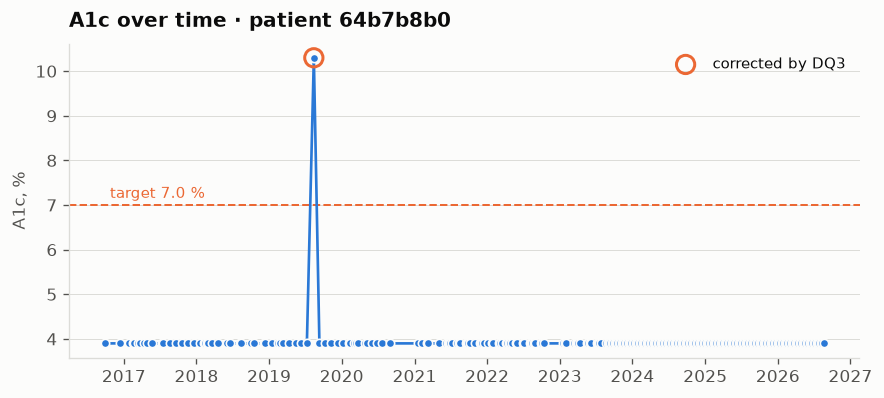

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(hist.date, hist.value, color=BLUE, lw=1.6, marker="o", ms=5,
        markeredgecolor=SURFACE, markeredgewidth=1, zorder=3)

# 7.0 % is the usual treatment target for most adults (ADA).
ax.axhline(7.0, color=ORANGE, lw=1.2, ls="--", zorder=2)
ax.text(hist.date.iloc[0], 7.08, " target 7.0 %", color=ORANGE, fontsize=9, va="bottom")

# Any result the pipeline corrected is marked, so a reader can discount it.
fixed = hist[hist._dq_status == "remediated"]
if len(fixed):
    ax.scatter(fixed.date, fixed.value, s=120, facecolor="none",
               edgecolor=ORANGE, lw=1.8, zorder=4, label="corrected by DQ3")
    ax.legend(frameon=False, fontsize=9)

ax.set_ylabel("A1c, %"); ax.grid(axis="x", visible=False)
ax.set_title(f"A1c over time · patient {pid[:8]}", loc="left",
             fontsize=12, fontweight="600", color=INK, pad=10)
plt.show()

### "What is this patient on, and when were they last seen?"

In [7]:
print("Active medications:")
display(ask(f"""
SELECT description, start_date, end_date
FROM silver_medications
WHERE patient_id = '{pid}'
  AND start_date <= DATE '{ASOF}'
  AND (end_date IS NULL OR end_date > DATE '{ASOF}')
ORDER BY start_date DESC
"""))

print("\nRecent encounters:")
display(ask(f"""
SELECT admission_ts::DATE AS date, encounter_type, description
FROM silver_encounters
WHERE patient_id = '{pid}' AND admission_ts <= TIMESTAMP '{ASOF}'
ORDER BY admission_ts DESC LIMIT 6
"""))

Active medications:


,description,start_date,end_date
0,insulin isophane human 70 UNT/ML / insulin regular hu...,2026-08-19,NaT
1,Hydrochlorothiazide 25 MG Oral Tablet,2026-08-19,NaT
2,Ibuprofen 400 MG Oral Tablet [Ibu],2026-08-19,NaT
3,Galantamine 4 MG Oral Tablet,2023-09-04,NaT
4,Simvastatin 10 MG Oral Tablet,2023-06-28,NaT



Recent encounters:


,date,encounter_type,description
0,2026-08-19,urgentcare,Urgent care clinic (environment)
1,2026-08-12,emergency,Emergency room admission (procedure)
2,2026-08-05,emergency,Emergency room admission (procedure)
3,2026-07-29,urgentcare,Urgent care clinic (environment)
4,2026-07-22,emergency,Emergency room admission (procedure)
5,2026-07-15,emergency,Emergency room admission (procedure)


### "Is the whole cohort drifting, or just this patient?"

,year,results,median_a1c,pct_above_target
3,2019,333,3.8,8.1
4,2020,293,3.8,6.8
5,2021,350,3.8,6.3
6,2022,332,3.8,5.1
7,2023,350,3.8,7.1
8,2024,422,3.9,4.0
9,2025,462,3.9,3.7
10,2026,261,3.9,5.4


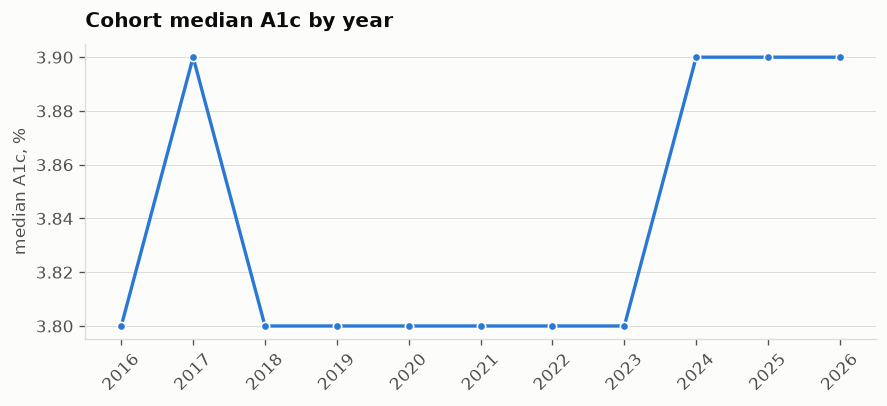

In [8]:
trend = ask(f"""
SELECT substr(observed_at::VARCHAR, 1, 4) AS year,
       count(*) AS results,
       round(median(value), 2) AS median_a1c,
       round(100.0 * count(*) FILTER (WHERE value >= 7.0) / count(*), 1) AS pct_above_target
FROM silver_observations
WHERE loinc_code = '{A1C}' AND value IS NOT NULL
  AND patient_id IN (SELECT patient_id FROM care_gap_a1c)
  AND observed_at <= TIMESTAMP '{ASOF}'
GROUP BY 1 HAVING count(*) > 30 ORDER BY 1
""")
display(trend.tail(8))

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.plot(trend.year, trend.median_a1c, color=BLUE, lw=2, marker="o", ms=5,
        markeredgecolor=SURFACE, markeredgewidth=1, zorder=3)
ax.set_ylabel("median A1c, %"); ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Cohort median A1c by year", loc="left", fontsize=12,
             fontweight="600", color=INK, pad=10)
plt.show()

## The question this project was built to answer

> **"Why isn't my patient on the list?"**

Every other care-gap report answers this with a shrug. Here the answer is a
query, because nothing was silently dropped — a row either reached Silver or it
is in `quarantine` with a reason attached.

The function below checks, in order: is the patient in the cohort at all, were
they excluded for a recorded reason, and is any of their data quarantined.

In [9]:
def why_not_in_report(patient_id):
    """Trace one patient. Answers 'why is this person missing from the list?'

    Checks the three ways a patient can be absent: no qualifying diagnosis,
    excluded by a recorded decision, or their row was quarantined by a check.
    """
    print(f"patient {patient_id[:8]}\n" + "-" * 46)

    pt = ask(f"SELECT * FROM silver_patients WHERE patient_id = '{patient_id}'")
    if pt.empty:
        q = ask(f"""SELECT check_id, failure_reason FROM quarantine
                     WHERE source_row_id = '{patient_id}'""")
        if not q.empty:
            print(f"  NOT in Silver. Quarantined by {q.check_id[0]}:")
            print(f"    {q.failure_reason[0]}")
        else:
            print("  No such patient in this extract.")
        return

    dx = ask(f"""SELECT snomed_code, description, onset_date FROM silver_conditions
                  WHERE patient_id = '{patient_id}' AND snomed_code IN ({DX})""")
    if dx.empty:
        near = ask(f"""SELECT DISTINCT description FROM silver_conditions
                        WHERE patient_id = '{patient_id}'
                          AND lower(description) LIKE '%diabet%'""")
        print("  Not in the cohort: no qualifying diabetes code.")
        if not near.empty:
            print("  They do carry:", ", ".join(near.description))
            print("  (prediabetes is deliberately excluded - see D5)")
        return
    print(f"  In the cohort on {len(dx)} code(s): {', '.join(dx.description.head(2))}")

    # pandas uses NaT for a missing date, and NaT is not None - testing for None
    # here reported every living patient as deceased, with a date of 'NaT'.
    if pd.notna(pt.death_date[0]):
        print(f"  Excluded: deceased {pt.death_date[0].date()}. "
              "A care-gap list is a call list (D5).")
        return

    gold = ask(f"SELECT * FROM care_gap_a1c WHERE patient_id = '{patient_id}'")
    if gold.empty:
        print("  In the cohort but not in Gold - this should not happen; check the build.")
        return

    g = gold.iloc[0]
    print(f"  In the report. gap_flag = {g.gap_flag}"
          + (f", priority {int(g.priority)}" if g.gap_flag else ""))
    # NaT is truthy, so `or` does not substitute for it either.
    last = f"{g.last_a1c_date.date()} ({g.last_a1c_value})" if pd.notna(g.last_a1c_date)            else "never tested - which is why they rank first"
    print(f"  Last A1c: {last}")

    rem = ask(f"""SELECT original_value, corrected_value, remediation_rule
                   FROM remediation_log WHERE source_row_id LIKE '%' || '{patient_id}' || '%'""")
    idr = ask(f"""SELECT status, confidence FROM identity_review
                   WHERE candidate_a_mrn = '{patient_id}' OR candidate_b_mrn = '{patient_id}'""")
    if not idr.empty:
        print(f"  ! This record is in identity review ({idr.status[0]}, "
              f"confidence {idr.confidence[0]}). Confirm before acting on it.")

# A patient who IS on the list
why_not_in_report(ask("SELECT patient_id FROM care_gap_a1c WHERE gap_flag ORDER BY priority LIMIT 1").patient_id[0])

patient dd31b260
----------------------------------------------
  In the cohort on 2 code(s): Disorder of kidney due to diabetes mellitus (disorder), Microalbuminuria due to type 2 diabetes mellitus (disorder)
  In the report. gap_flag = True, priority 1
  Last A1c: never tested - which is why they rank first


Now one who is **not** — a prediabetic, deliberately excluded:

In [10]:
pre = ask("""
SELECT patient_id FROM silver_conditions
WHERE snomed_code = '714628002'
  AND patient_id NOT IN (SELECT patient_id FROM care_gap_a1c)
LIMIT 1
""").patient_id[0]
why_not_in_report(pre)

patient 59a63d88
----------------------------------------------
  Not in the cohort: no qualifying diabetes code.
  They do carry: Prediabetes (finding)
  (prediabetes is deliberately excluded - see D5)


And one excluded because they died before the as-of date:

In [11]:
dead = ask(f"""
SELECT c.patient_id FROM silver_conditions c JOIN silver_patients p USING (patient_id)
WHERE c.snomed_code IN ({DX}) AND p.death_date <= DATE '{ASOF}'
LIMIT 1
""").patient_id[0]
why_not_in_report(dead)

patient 610ee28a
----------------------------------------------
  In the cohort on 3 code(s): Disorder of kidney due to diabetes mellitus (disorder), Microalbuminuria due to type 2 diabetes mellitus (disorder)
  Excluded: deceased 1968-09-28. A care-gap list is a call list (D5).


That is the data quality layer paying off. Three patients are absent from the
report for three different reasons, and each reason is recoverable — not
guessed at.

## Your scratch space

Write anything below. `ask(sql)` returns a DataFrame; the tables available are:

`care_gap_a1c` · `silver_patients` · `silver_observations` · `silver_conditions`
· `silver_encounters` · `silver_medications` · `quarantine` · `identity_review`
· `remediation_log` · and the `bronze_*` tables if you need to see what arrived.

The connection is **read-only**, so nothing here can change the warehouse.

In [12]:
ask("""
-- your question here
SELECT * FROM care_gap_a1c LIMIT 5
""")

,patient_id,age,last_a1c_date,last_a1c_value,days_since_a1c,gap_flag,active_med_count,asof_date,next_due_date,days_overdue,a1c_count_2y,first_dx_date,last_a1c_controlled,last_encounter_date,identity_review_pending,on_insulin,priority
0,dd31b260-5ad0-2bff-3218-031136ec287c,85,NaT,NaN,<NA>,True,4,2026-08-23,NaT,<NA>,0,2013-09-21,<NA>,2026-05-23,False,False,1
1,23018670-880f-61c0-1ede-08c641bd8f84,79,NaT,NaN,<NA>,True,12,2026-08-23,NaT,<NA>,0,2016-07-17,<NA>,2026-07-26,False,False,2
2,cb213d00-b093-9237-bfa6-aff0aace6281,75,NaT,NaN,<NA>,True,11,2026-08-23,NaT,<NA>,0,2014-11-03,<NA>,2026-05-18,False,False,3
3,ff8b6ec6-50ab-03eb-66dc-50a6b96fb572,75,NaT,NaN,<NA>,True,6,2026-08-23,NaT,<NA>,0,2012-05-13,<NA>,2026-07-05,False,False,4
4,8670ef45-e53b-be2d-3cb7-2fb40a2343ce,73,NaT,NaN,<NA>,True,6,2026-08-23,NaT,<NA>,0,2025-04-12,<NA>,2026-08-22,False,False,5


## Release the database

DuckDB allows one writer. Run this before `make run`, or the pipeline cannot
open the file — closing the notebook tab does not stop the kernel.

In [13]:
con.close()
print("connection closed - the pipeline can run now")

connection closed - the pipeline can run now
